# Создание датасета с координатами паттерна "Голова и плечи"

В этом ноутбуке мы создадим полноценный датасет с использованием существующего кода для обнаружения паттернов и будем сохранять не только информацию о наличии паттерна, но и его координаты (начало и конец).

## 1. Загрузка необходимых библиотек

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [13]:
def generate_head_shoulders_pattern(window_size=120, pattern_start=None, pattern_end=None):
    """
    Умеренно выраженный паттерн "голова и плечи"
    (не слишком очевидный, но различимый)
    """
    # Базовый ряд (возвращаем влияние рынка)
    t = np.linspace(0, 4*np.pi, window_size)
    ts = 0.25 * np.sin(t) + 0.15 * np.sin(2*t)
    ts += np.random.normal(0, 0.06, window_size)
    
    # Координаты
    if pattern_start is None:
        pattern_start = np.random.randint(20, window_size - 60)
    if pattern_end is None:
        pattern_end = np.random.randint(pattern_start + 40, window_size - 10)
    
    pattern_len = pattern_end - pattern_start
    
    # Ключевые точки
    ls_peak = pattern_start + pattern_len // 6
    head_peak = pattern_start + pattern_len // 2
    rs_peak = pattern_start + 5 * pattern_len // 6
    
    base_level = ts[pattern_start]
    
    # Амплитуды (менее агрессивные)
    shoulder_amp = 0.35 + np.random.uniform(-0.05, 0.05)
    head_amp = 0.6 + np.random.uniform(-0.1, 0.1)
    
    # === ЛЕВОЕ ПЛЕЧО ===
    ts[pattern_start:ls_peak] += np.linspace(0, shoulder_amp, ls_peak - pattern_start)
    ts[ls_peak:pattern_start + pattern_len // 3] += np.linspace(shoulder_amp, 0, pattern_len // 3 - (ls_peak - pattern_start))
    
    # === ГОЛОВА ===
    head_start = pattern_start + pattern_len // 3
    head_end = pattern_start + 2 * pattern_len // 3
    
    ts[head_start:head_peak] += np.linspace(0, head_amp, head_peak - head_start)
    ts[head_peak:head_end] += np.linspace(head_amp, 0, head_end - head_peak)
    
    # === ПРАВОЕ ПЛЕЧО ===
    ts[head_end:rs_peak] += np.linspace(0, shoulder_amp, rs_peak - head_end)
    ts[rs_peak:pattern_end] += np.linspace(shoulder_amp, 0, pattern_end - rs_peak)
    
    # Лёгкий наклон (реалистичность)
    slope = np.random.uniform(-0.1, 0.1)
    ts[pattern_start:pattern_end] += np.linspace(0, slope, pattern_len)
    
    # Нормализация
    ts = (ts - ts.mean()) / (ts.std() + 1e-8)
    
    return ts, pattern_start / window_size, pattern_end / window_size

In [14]:
# Параметры датасета
WINDOW_SIZE = 120
NUM_PATTERNS = 300  # Ряды с паттернами
NUM_RANDOM = 300    # Ряды без паттернов
RANDOM_STATE = 42

print(f"Генерирование датасета...")
print(f"  - С паттернами: {NUM_PATTERNS}")
print(f"  - Без паттернов: {NUM_RANDOM}")

X_list = []
y_list = []
start_list = []
end_list = []

# Генерируем ряды с паттернами
for i in range(NUM_PATTERNS):
    ts, norm_start, norm_end = generate_head_shoulders_pattern(WINDOW_SIZE)
    X_list.append(ts)
    y_list.append(1.0)
    start_list.append(norm_start)
    end_list.append(norm_end)

# Генерируем ряды без паттернов
for i in range(NUM_RANDOM):
    ts = generate_random_timeseries(WINDOW_SIZE)
    X_list.append(ts)
    y_list.append(0.0)
    start_list.append(-1.0)
    end_list.append(-1.0)

# Преобразуем в массивы
X = np.array(X_list)
y = np.array(y_list)
start = np.array(start_list)
end = np.array(end_list)

print(f"✓ Датасет создан: {len(X)} образцов")
print(f"  - С паттернами: {(y == 1).sum()}")
print(f"  - Без паттернов: {(y == 0).sum()}")

Генерирование датасета...
  - С паттернами: 300
  - Без паттернов: 300
✓ Датасет создан: 600 образцов
  - С паттернами: 300
  - Без паттернов: 300


In [15]:
# Разделяем на train и test (80/20)
X_train, X_test, y_train, y_test, start_train, start_test, end_train, end_test = train_test_split(
    X, y, start, end, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"✓ Разделены на train/test (80/20):")
print(f"  Train: {len(X_train)} образцов ({(y_train == 1).sum()} с паттернами)")
print(f"  Test:  {len(X_test)} образцов ({(y_test == 1).sum()} с паттернами)")

# Функция для сохранения в CSV
def save_dataset_to_csv(X, y, start, end, filename):
    """Сохраняет датасет в CSV формате"""
    data = {}
    for i in range(WINDOW_SIZE):
        data[f't{i}'] = X[:, i]
    data['has_pattern'] = y
    data['pattern_start'] = start
    data['pattern_end'] = end
    
    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    print(f"✓ Сохранено в {filename} ({len(df)} образцов)")

# Сохраняем в CSV
save_dataset_to_csv(X_train, y_train, start_train, end_train, 'train.csv')
save_dataset_to_csv(X_test, y_test, start_test, end_test, 'test.csv')

✓ Разделены на train/test (80/20):
  Train: 480 образцов (240 с паттернами)
  Test:  120 образцов (60 с паттернами)
✓ Сохранено в train.csv (480 образцов)
✓ Сохранено в test.csv (120 образцов)


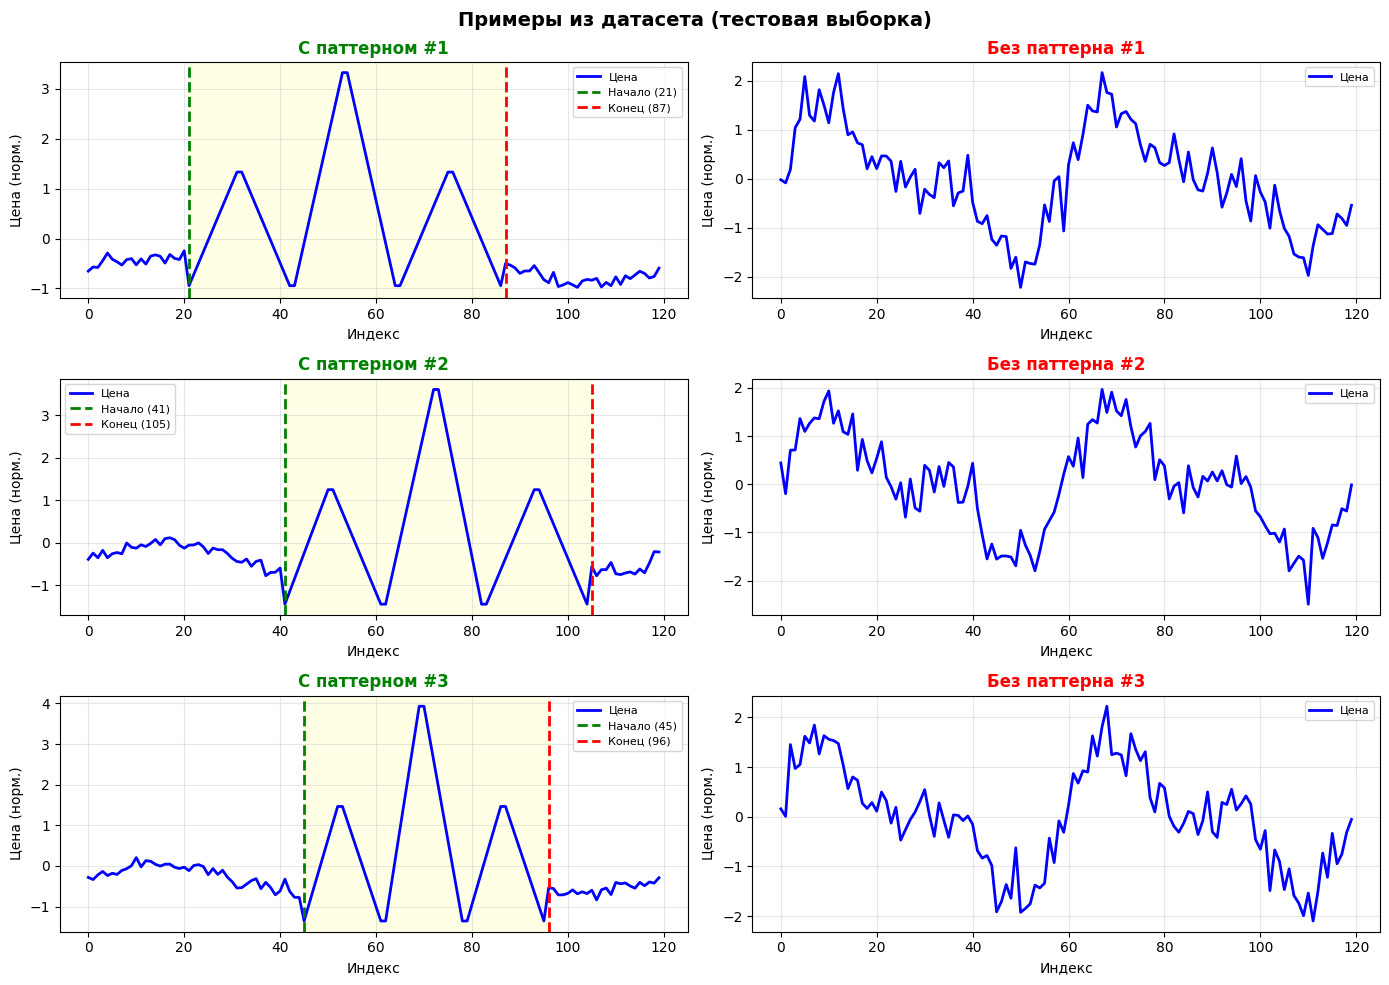

✓ Визуализация сохранена в dataset_examples.png


In [11]:
# Выбираем примеры с паттернами и без из данных
with_pattern_idx = np.where(y_test == 1)[0]
without_pattern_idx = np.where(y_test == 0)[0]

# Визуализация
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Примеры из датасета (тестовая выборка)', fontsize=14, fontweight='bold')

# Примеры с паттернами
for i in range(3):
    ax = axes[i, 0]
    idx = with_pattern_idx[i]
    
    # Извлекаем временной ряд из X_test
    ts = X_test[idx]
    start_norm = start_test[idx]
    end_norm = end_test[idx]
    
    start_idx = int(start_norm * WINDOW_SIZE)
    end_idx = int(end_norm * WINDOW_SIZE)
    
    ax.plot(range(WINDOW_SIZE), ts, 'b-', linewidth=2, label='Цена')
    ax.axvline(start_idx, color='green', linestyle='--', linewidth=2, label=f'Начало ({start_idx})')
    ax.axvline(end_idx, color='red', linestyle='--', linewidth=2, label=f'Конец ({end_idx})')
    ax.axvspan(start_idx, end_idx, alpha=0.1, color='yellow')
    
    ax.set_title(f'С паттерном #{i+1}', fontweight='bold', color='green')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Цена (норм.)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Примеры без паттернов
for i in range(3):
    ax = axes[i, 1]
    idx = without_pattern_idx[i]
    
    ts = X_test[idx]
    
    ax.plot(range(WINDOW_SIZE), ts, 'b-', linewidth=2, label='Цена')
    ax.set_title(f'Без паттерна #{i+1}', fontweight='bold', color='red')
    ax.set_xlabel('Индекс')
    ax.set_ylabel('Цена (норм.)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Визуализация сохранена в dataset_examples.png")